<a href="https://colab.research.google.com/github/YellaSrinisha/MDS_Lab/blob/main/MDS_hugging_face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_parquet("house prediction.parquet")
df.to_csv("house prediction dataset.csv", index=False)

from google.colab import files
files.download("house prediction dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#from google.colab import files
#uploaded = files.upload()

In [6]:
import pandas as pd

df = pd.read_csv("house prediction dataset.csv")
print(df.columns)
print(df.shape)
print(df.head())


Index(['id', 'city', 'property_type', 'area_sqft', 'bedrooms', 'bathrooms',
       'floors', 'floor_number', 'year_built', 'age_years', 'condition',
       'furnishing', 'parking_spaces', 'has_garden', 'has_pool',
       'distance_to_city_center_km', 'near_school', 'near_hospital',
       'crime_rate_index', 'price_bdt'],
      dtype='object')
(5000, 20)
<bound method NDFrame.head of         id        city property_type  area_sqft  bedrooms  bathrooms  floors  \
0        1  Chattogram     Apartment       1601         2          1      23   
1        2       Dhaka        Duplex       2728         3          3       1   
2        3    Barishal         House       1527         2          2       2   
3        4      Khulna     Apartment       1694         1          1      16   
4        5      Sylhet     Apartment       2153         3          3      24   
...    ...         ...           ...        ...       ...        ...     ...   
4995  4996      Khulna        Duplex       2230      

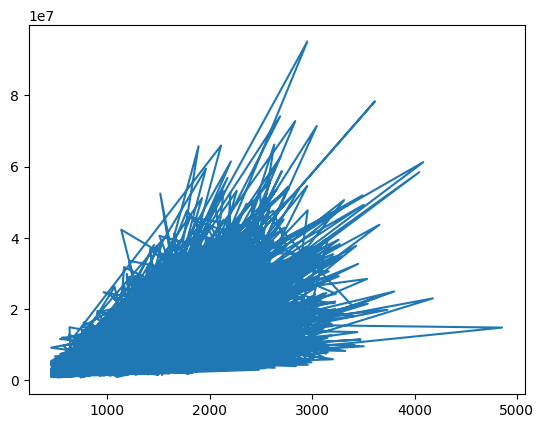

In [8]:
import matplotlib.pyplot as plt
#line plot
plt.plot(df["area_sqft"], df["price_bdt"])
plt.show()

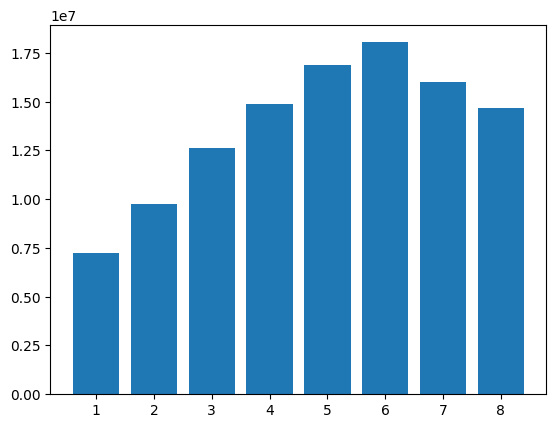

In [9]:
#bar plot
avg_price = df.groupby("bedrooms")["price_bdt"].mean()

plt.bar(avg_price.index, avg_price.values)
plt.show()

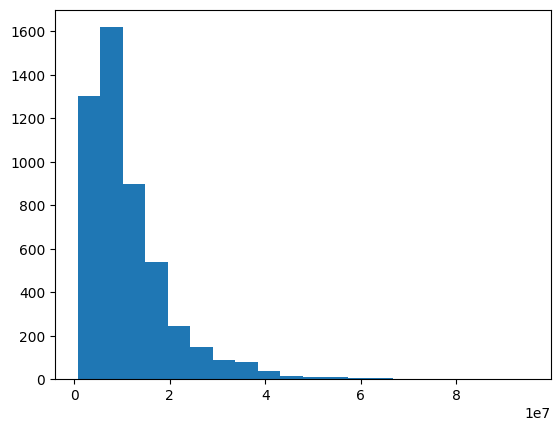

In [10]:
#hist plot
plt.hist(df["price_bdt"], bins=20)
plt.show()

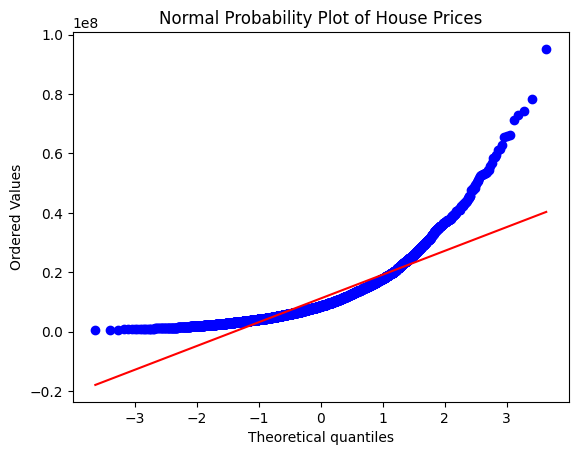

In [12]:
#normal probability plot
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df["price_bdt"], dist="norm", plot=plt)
plt.title("Normal Probability Plot of House Prices")
plt.show()

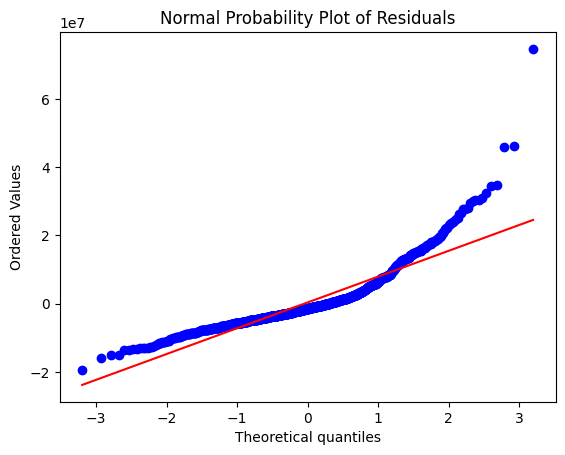

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load data
df = pd.read_csv("house prediction dataset.csv")

# Input and output
X = df[["area_sqft"]]
y = df["price_bdt"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Normal probability plot
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Probability Plot of Residuals")
plt.show()

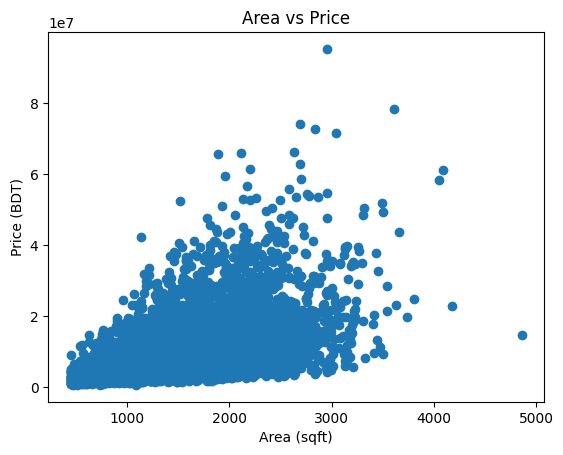

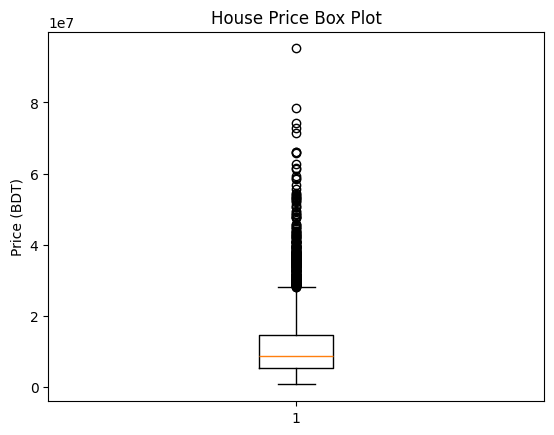

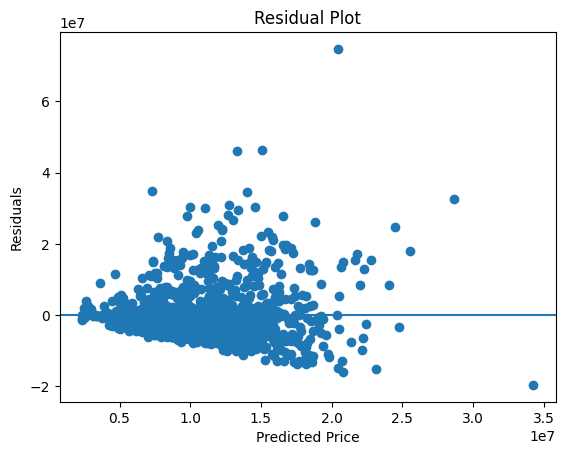

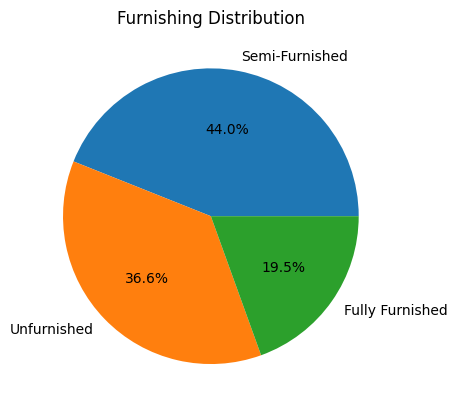

In [15]:
import matplotlib.pyplot as plt

# Scatter plot
plt.scatter(df["area_sqft"], df["price_bdt"])
plt.xlabel("Area (sqft)")
plt.ylabel("Price (BDT)")
plt.title("Area vs Price")
plt.show()


# Box plot
plt.boxplot(df["price_bdt"])
plt.title("House Price Box Plot")
plt.ylabel("Price (BDT)")
plt.show()


# Residual plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


# Pie chart
df["furnishing"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Furnishing Distribution")
plt.ylabel("")
plt.show()

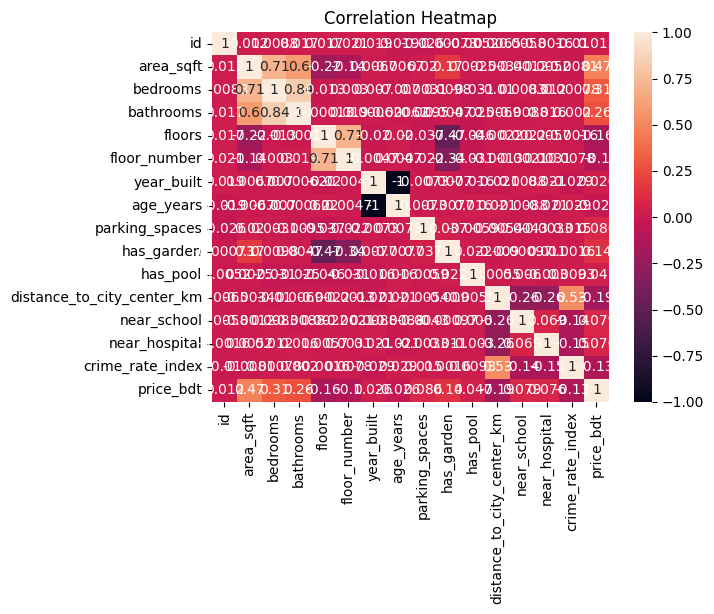

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes("number").corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()